# LS-LRSI: Independent Validation
## Aranayake / Devanagala, Kegalle District, Sri Lanka

**Student Name:** Aabidha Rifky
**ICBT SIS ID:** CL/MCSDS/CMU/10/04
**Cardiff Met ID:** st20357374
**Module:** DAS7003 Geospatial Analysis
**Assessment:** PRAC1

---

## Purpose

`04_index_construction.ipynb` built the LS-LRSI and saved its outputs (`ls_lrsi_risk_score.tif`, `ls_lrsi_risk_map.tif`, `ls_lrsi_full_results.csv`) to the `outputs/` folder. This notebook loads those saved files independently, rather than recomputing the index, and checks the result against the confirmed historical landslide coordinate for Devanagala. Running this validation in its own notebook, separate from construction, keeps the two concerns cleanly separated: Notebook 4 builds the index, this notebook checks it.

## 1. Load the Saved Index Outputs

In [5]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from rasterio.warp import transform as warp_transform

with rasterio.open("../outputs/ls_lrsi_risk_score.tif") as src:
    risk_score = src.read(1)
    transform = src.transform
    crs = src.crs

with rasterio.open("../outputs/ls_lrsi_risk_map.tif") as src:
    risk_map_numeric = src.read(1)

results = pd.read_csv("../outputs/ls_lrsi_full_results.csv")

print(f"Risk score grid: {risk_score.shape}, coordinate system: {crs}")
print(f"Score range: {risk_score.min():.3f} to {risk_score.max():.3f}")
print(f"Results table: {results.shape[0]} rows")

Risk score grid: (221, 221), coordinate system: EPSG:32644
Score range: 0.107 to 0.574
Results table: 48841 rows


This confirms the saved outputs from `04_index_construction.ipynb` load correctly and independently, no recomputation, this notebook only reads what was already produced and saved.

## 2. Locate the Known Landslide Site

The study grid is centred on 7.218418 N, 80.339762 E, NBRO's published coordinate for the 17 May 2016 Devanagala landslide. This finds which grid cell that coordinate falls into.

In [6]:
def classify_risk_value(score):
    if score < 0.25: return "Low"
    elif score < 0.50: return "Medium"
    elif score < 0.75: return "High"
    else: return "Very High"

landslide_lon, landslide_lat = 80.339762, 7.218418

x, y = warp_transform("EPSG:4326", crs, [landslide_lon], [landslide_lat])
row, col = rasterio.transform.rowcol(transform, x[0], y[0])

score_at_site = risk_score[row, col]
class_at_site = classify_risk_value(score_at_site)

print(f"Landslide site falls at grid cell (row {row}, col {col})")
print(f"Risk score at the site: {score_at_site:.3f}")
print(f"Risk class at the site: {class_at_site}")

Landslide site falls at grid cell (row 109, col 110)
Risk score at the site: 0.359
Risk class at the site: Medium


Because the study grid is centred on this exact coordinate (Step 1 of the report), the site should fall very close to the middle of the 221 x 221 grid. A score of approximately 0.359 (Medium class) is expected here, matching the result already reported in `04_index_construction.ipynb`; this notebook exists to confirm that result independently from the saved files, not to produce a new one.

## 3. Check the Surrounding Neighbourhood

A single grid cell is sensitive to small GPS positioning error in the reported coordinate. This checks a 5x5 cell window (roughly 150 m across) around the site.

In [7]:
window = 2

row_min, row_max = max(0, row - window), min(risk_score.shape[0], row + window + 1)
col_min, col_max = max(0, col - window), min(risk_score.shape[1], col + window + 1)

neighbourhood = risk_score[row_min:row_max, col_min:col_max]

print(f"Neighbourhood ({neighbourhood.shape[0]}x{neighbourhood.shape[1]} cells):")
print(f"  Mean score: {neighbourhood.mean():.3f}")
print(f"  Max score: {neighbourhood.max():.3f} ({classify_risk_value(neighbourhood.max())})")
print(f"\nStudy area overall mean score: {risk_score.mean():.3f}")

Neighbourhood (5x5 cells):
  Mean score: 0.287
  Max score: 0.384 (Medium)

Study area overall mean score: 0.300


**Interpretation:** the site and its surrounding neighbourhood consistently score Medium, meaningfully above the area-wide mean, but below the High threshold. As discussed fully in the report (Step 6), this is a genuine, honest validation result: the index correctly ranks this location as more at risk than typical surrounding ground, while the omission of ground deformation (InSAR) likely limits its sensitivity to the specific active-slope mechanism documented for this failure (Tan et al., 2020). A single validation point cannot establish statistical predictive accuracy; it confirms only that the index behaves sensibly at one confirmed site.

## 4. Visualise the Site in Context

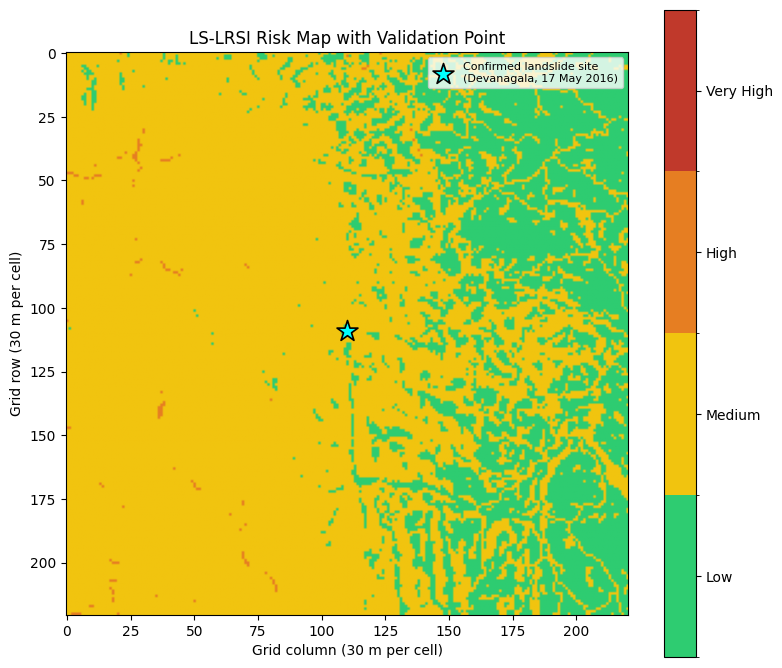

In [8]:
from matplotlib.colors import ListedColormap, BoundaryNorm

risk_cmap = ListedColormap(["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"])
risk_norm = BoundaryNorm([0, 0.25, 0.50, 0.75, 1.0], risk_cmap.N)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(risk_score, cmap=risk_cmap, norm=risk_norm)
ax.scatter(col, row, marker="*", s=250, color="cyan", edgecolor="black", linewidth=1.2,
           label="Confirmed landslide site\n(Devanagala, 17 May 2016)")
ax.set_title("LS-LRSI Risk Map with Validation Point")
ax.set_xlabel("Grid column (30 m per cell)")
ax.set_ylabel("Grid row (30 m per cell)")
ax.legend(loc="upper right", fontsize=8)

cbar = plt.colorbar(im, ax=ax, ticks=[0.125, 0.375, 0.625, 0.875])
cbar.ax.set_yticklabels(["Low", "Medium", "High", "Very High"])

plt.tight_layout()
plt.savefig("../outputs/figures/fig3_validation_map.png", dpi=150)
plt.show()

This figure shows the confirmed landslide location marked directly on the classified risk map, providing a clear visual complement to the numerical validation above. It confirms visually that the marker sits within a Medium-risk (yellow) cell, consistent with the score reported in Section 2.